XOM vs CVX

In [7]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler


In [ ]:
file_cvx_path = '/Users/wesleylu/Desktop/CS4641/linear_regression/cvx.us.txt'
file_xom_path = '/Users/wesleylu/Desktop/CS4641/linear_regression/xom.us.txt'

xom_data = pd.read_csv(file_xom_path)
cvx_data = pd.read_csv(file_cvx_path)

xom_data['Log_Close'] = np.log(xom_data['Close'])
cvx_data['Log_Close'] = np.log(cvx_data['Close'])

xom_output_path = 'xom_with_log.csv'
cvx_output_path = 'cvx_with_log.csv'

xom_data.to_csv(xom_output_path, index=False)
cvx_data.to_csv(cvx_output_path, index=False)

print(f"XOM file with log-transformed prices saved to: {xom_output_path}")
print(f"CVX file with log-transformed prices saved to: {cvx_output_path}")


XOM file with log-transformed prices saved to: xom_with_log.csv
CVX file with log-transformed prices saved to: cvx_with_log.csv


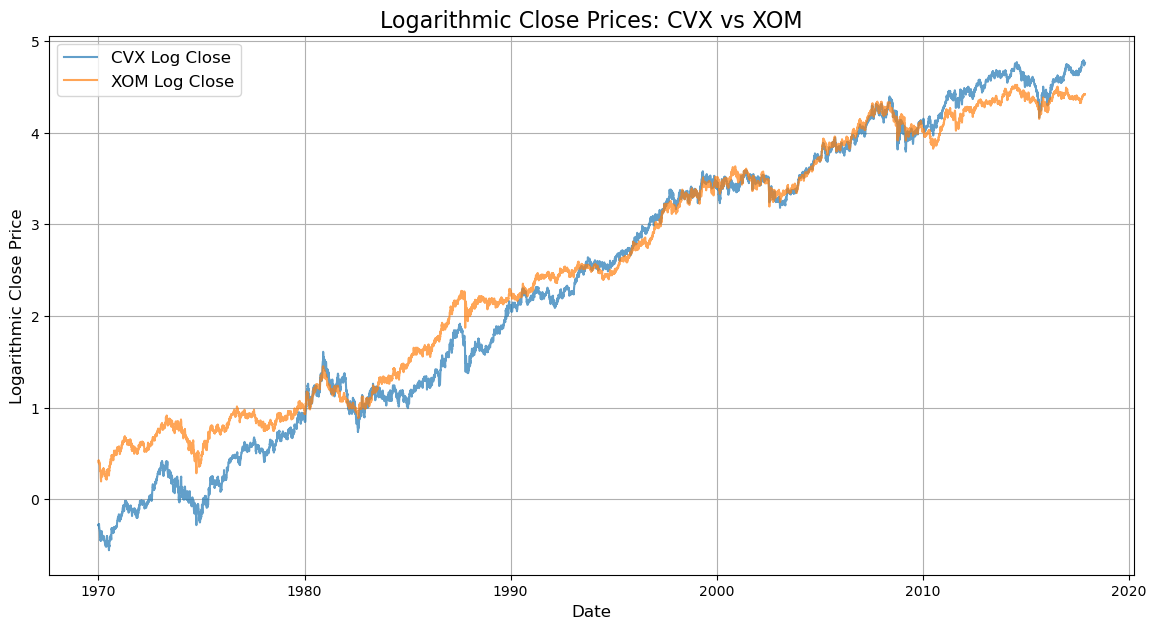

In [ ]:
cvx_data['Date'] = pd.to_datetime(cvx_data['Date'])
xom_data['Date'] = pd.to_datetime(xom_data['Date'])
plt.figure(figsize=(14, 7))
plt.plot(cvx_data['Date'], cvx_data['Log_Close'], label='CVX Log Close', alpha=0.7)
plt.plot(xom_data['Date'], xom_data['Log_Close'], label='XOM Log Close', alpha=0.7)

plt.title('Logarithmic Close Prices: CVX vs XOM', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Logarithmic Close Price', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)


plt.show()


Intercept (alpha): -0.5197285432414263
Slope (beta): 1.1552370224700717


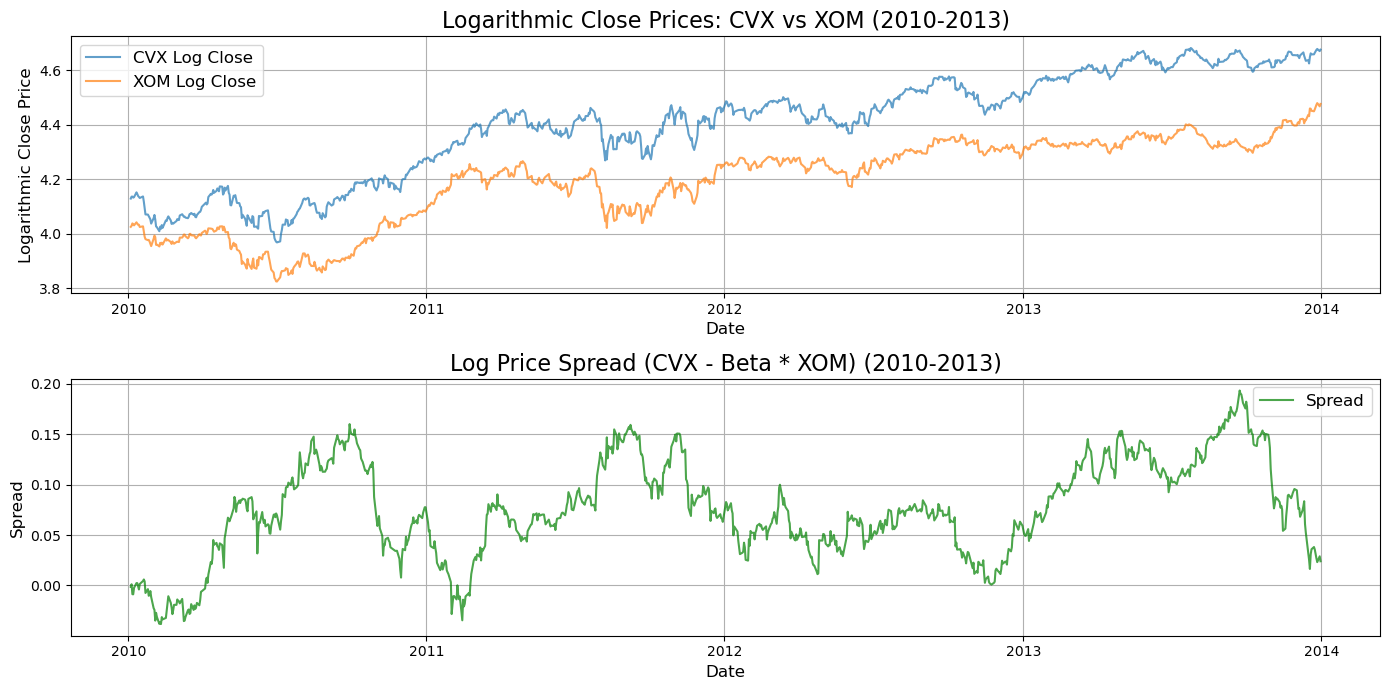

Data with spread from 2010-2013 saved to: filtered_data_with_spread_2010_2013.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression


file_cvx_path = '/Users/wesleylu/Desktop/CS4641/spread_models/cvx.us.txt'
file_xom_path = '/Users/wesleylu/Desktop/CS4641/spread_models/xom.us.txt'

xom_data = pd.read_csv(file_xom_path)
cvx_data = pd.read_csv(file_cvx_path)

xom_data['Log_Close'] = np.log(xom_data['Close'])
cvx_data['Log_Close'] = np.log(cvx_data['Close'])

merged_data = pd.merge(xom_data[['Date', 'Log_Close']], cvx_data[['Date', 'Log_Close']], on='Date', suffixes=('_XOM', '_CVX'))
merged_data['Date'] = pd.to_datetime(merged_data['Date'])

X = merged_data['Log_Close_XOM'].values.reshape(-1, 1) 
y = merged_data['Log_Close_CVX'].values  


model = LinearRegression()
model.fit(X, y)

alpha = model.intercept_
beta = model.coef_[0]
print(f"Intercept (alpha): {alpha}")
print(f"Slope (beta): {beta}")

merged_data['Spread'] = merged_data['Log_Close_CVX'] - (beta * merged_data['Log_Close_XOM'] + alpha)

start_date = '2010-01-01'
end_date = '2013-12-31'
filtered_data = merged_data[(merged_data['Date'] >= start_date) & (merged_data['Date'] <= end_date)]


plt.figure(figsize=(14, 7))


plt.subplot(2, 1, 1)
plt.plot(filtered_data['Date'], filtered_data['Log_Close_CVX'], label='CVX Log Close', alpha=0.7)
plt.plot(filtered_data['Date'], filtered_data['Log_Close_XOM'], label='XOM Log Close', alpha=0.7)
plt.title('Logarithmic Close Prices: CVX vs XOM (2010-2013)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Logarithmic Close Price', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)


plt.gca().xaxis.set_major_locator(mdates.YearLocator()) 
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))


plt.subplot(2, 1, 2)
plt.plot(filtered_data['Date'], filtered_data['Spread'], label='Spread', color='green', alpha=0.7)
plt.title('Log Price Spread (CVX - Beta * XOM) (2010-2013)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Spread', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))


plt.tight_layout()
plt.show()

spread_output_path = 'filtered_data_with_spread_2010_2013.csv'
filtered_data.to_csv(spread_output_path, index=False)
print(f"Data with spread from 2010-2013 saved to: {spread_output_path}")


Intercept (alpha): -0.5197285432414263
Slope (beta): 1.1552370224700717


/var/folders/8l/9f8bkrp10_j_nv1019x4c4lr0000gn/T/ipykernel_97529/3758740700.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['Rolling_Mean'] = filtered_data['Spread'].rolling(window=window).mean()
/var/folders/8l/9f8bkrp10_j_nv1019x4c4lr0000gn/T/ipykernel_97529/3758740700.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['Rolling_Std'] = filtered_data['Spread'].rolling(window=window).std()
/var/folders/8l/9f8bkrp10_j_nv1019x4c4lr0000gn/T/ipykernel_97529/3758740700.py:55: S

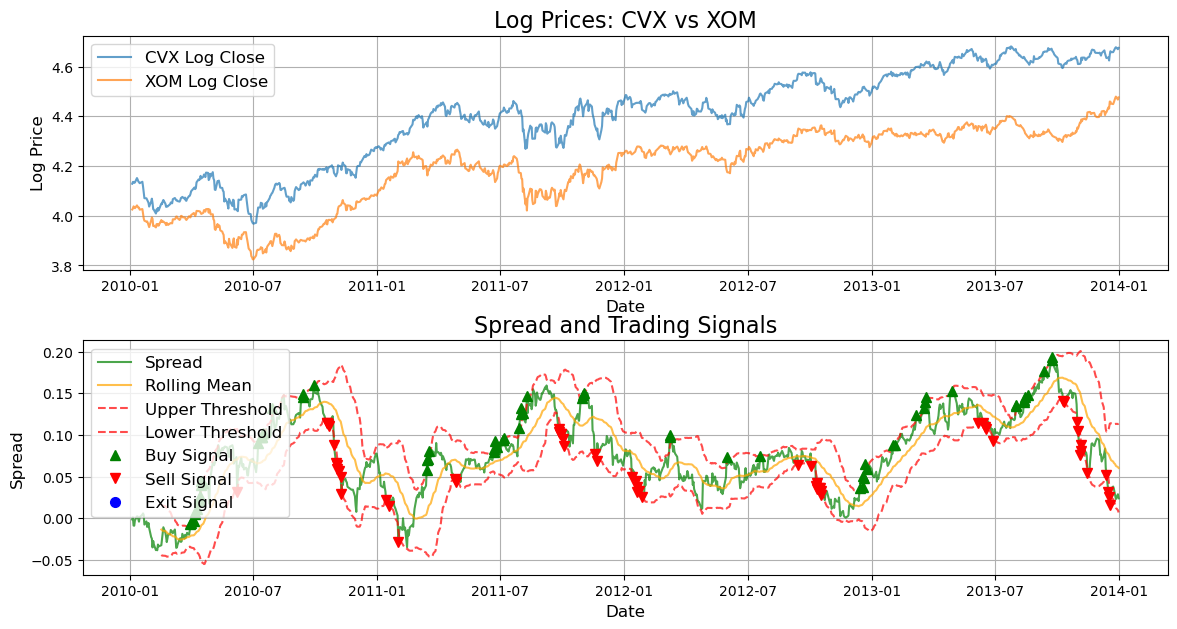

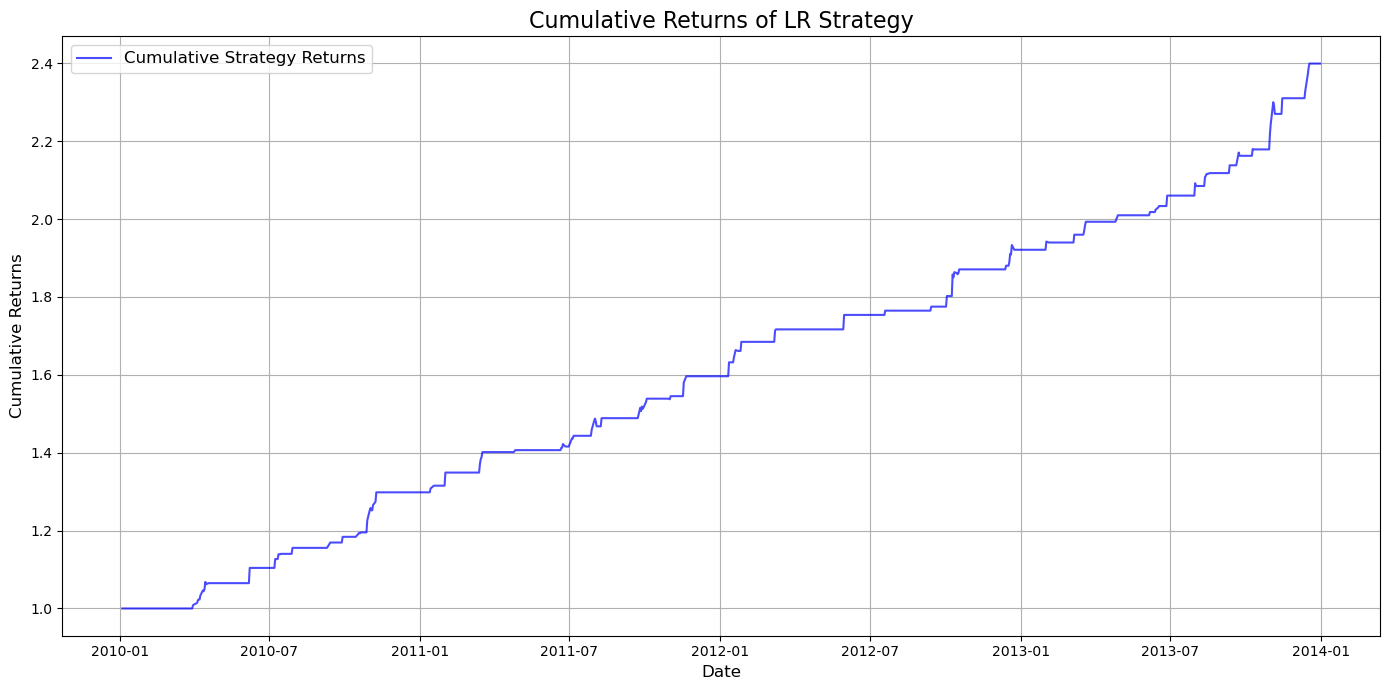

Data with strategy returns saved to: filtered_data_with_strategy_returns.csv
Cumulative Return: 139.94%
Annualized Sharpe Ratio: 3.72
Number of Long Trades (Buy CVX, Short XOM): 67
Number of Short Trades (Sell CVX, Buy XOM): 58
Total Number of Trades: 125


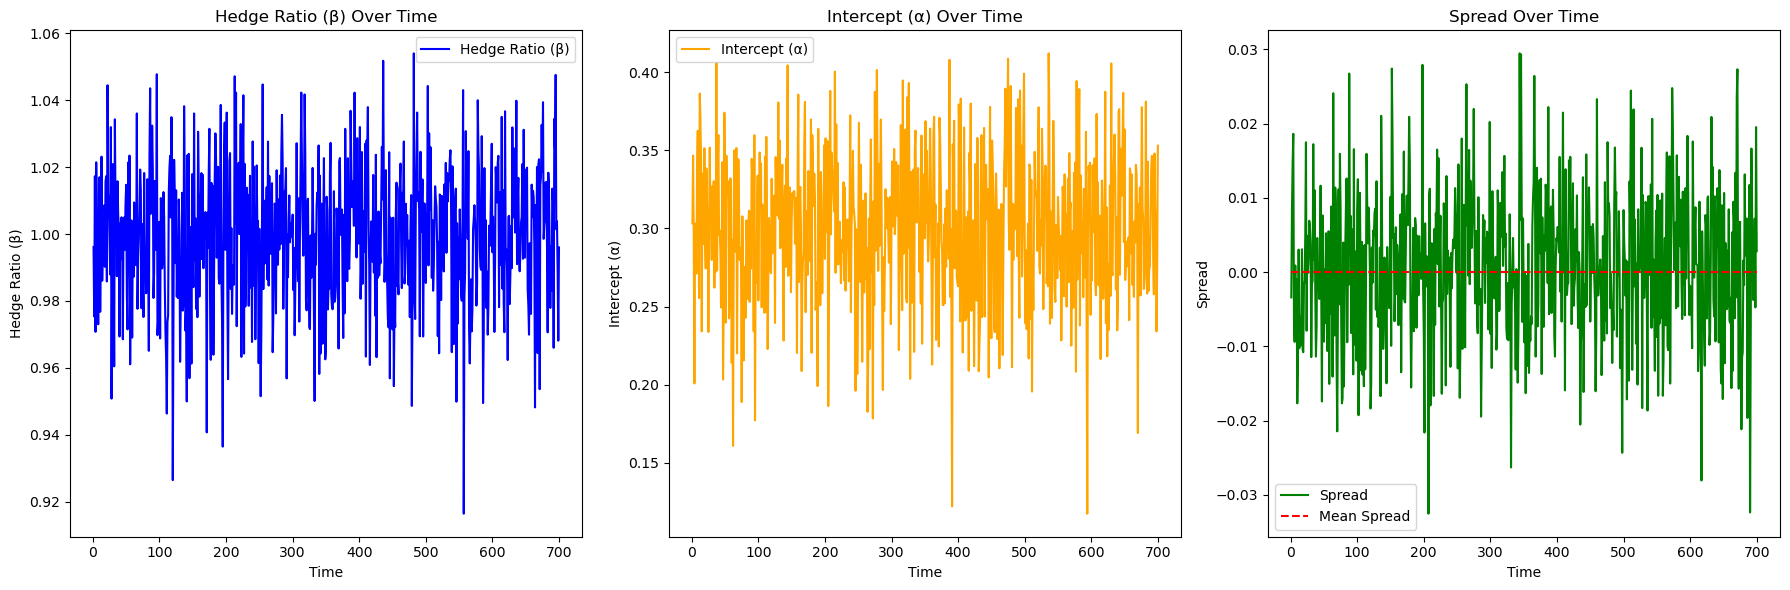

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression

# Load your data (already done)
file_cvx_path = '/Users/wesleylu/Desktop/CS4641/spread_models/cvx.us.txt'
file_xom_path = '/Users/wesleylu/Desktop/CS4641/spread_models/xom.us.txt'

xom_data = pd.read_csv(file_xom_path)
cvx_data = pd.read_csv(file_cvx_path)

# Log transformation (already done)
xom_data['Log_Close'] = np.log(xom_data['Close'])
cvx_data['Log_Close'] = np.log(cvx_data['Close'])

# Ensure both datasets align in time (merge on Date)
merged_data = pd.merge(xom_data[['Date', 'Log_Close']], cvx_data[['Date', 'Log_Close']], on='Date', suffixes=('_XOM', '_CVX'))

# Convert the 'Date' column to datetime for better handling
merged_data['Date'] = pd.to_datetime(merged_data['Date'])

# Step 1: Prepare the data for Linear Regression
X = merged_data['Log_Close_XOM'].values.reshape(-1, 1)  # Independent variable (XOM Log_Close)
y = merged_data['Log_Close_CVX'].values  # Dependent variable (CVX Log_Close)

# Step 2: Fit the Linear Regression model
model = LinearRegression()
model.fit(X, y)

# Step 3: Get the model parameters
alpha = model.intercept_
beta = model.coef_[0]
print(f"Intercept (alpha): {alpha}")
print(f"Slope (beta): {beta}")

# Step 4: Calculate the spread (log price difference)
merged_data['Spread'] = merged_data['Log_Close_CVX'] - (beta * merged_data['Log_Close_XOM'] + alpha)

# Step 5: Filter data to include only the range from 2010 to 2013
start_date = '2010-01-01'
end_date = '2013-12-31'
filtered_data = merged_data[(merged_data['Date'] >= start_date) & (merged_data['Date'] <= end_date)]

# Step 6: Calculate the rolling mean and standard deviation of the spread
window = 30  # Use 30-day window for rolling statistics
filtered_data['Rolling_Mean'] = filtered_data['Spread'].rolling(window=window).mean()
filtered_data['Rolling_Std'] = filtered_data['Spread'].rolling(window=window).std()

# Step 7: Define trading signals based on spread deviation from the rolling mean
threshold = 2  # 2 standard deviations from the mean as the threshold for trading signals

# Buy signal: Spread > Rolling Mean + threshold * Rolling Std
filtered_data['Long_Signal'] = filtered_data['Spread'] > (filtered_data['Rolling_Mean'] + threshold * filtered_data['Rolling_Std'])

# Sell signal: Spread < Rolling Mean - threshold * Rolling Std
filtered_data['Short_Signal'] = filtered_data['Spread'] < (filtered_data['Rolling_Mean'] - threshold * filtered_data['Rolling_Std'])

# Exit signal: When the spread reverts to the mean
filtered_data['Exit_Signal'] = (filtered_data['Spread'] >= filtered_data['Rolling_Mean']) & (filtered_data['Spread'] <= filtered_data['Rolling_Mean'])

# Step 8: Calculate daily returns for CVX and XOM
filtered_data['Return_CVX'] = filtered_data['Log_Close_CVX'].diff()  # Log difference for CVX (daily return)
filtered_data['Return_XOM'] = filtered_data['Log_Close_XOM'].diff()  # Log difference for XOM (daily return)

# Step 9: Define strategy returns based on signals
filtered_data['Strategy_Return'] = 0  # Initialize strategy returns

# Long signal: Buy CVX, Short XOM
filtered_data.loc[filtered_data['Long_Signal'], 'Strategy_Return'] = filtered_data['Return_CVX'] - filtered_data['Return_XOM']

# Short signal: Sell CVX, Buy XOM
filtered_data.loc[filtered_data['Short_Signal'], 'Strategy_Return'] = -(filtered_data['Return_CVX'] - filtered_data['Return_XOM'])

# Exit signal: Close positions (no return)
filtered_data.loc[filtered_data['Exit_Signal'], 'Strategy_Return'] = 0

# Step 10: Calculate cumulative returns
filtered_data['Cumulative_Strategy_Returns'] = (1 + filtered_data['Strategy_Return']).cumprod()

# Step 11: Plot the results
plt.figure(figsize=(14, 7))

# Plot Log_Close of CVX vs XOM
plt.subplot(2, 1, 1)
plt.plot(filtered_data['Date'], filtered_data['Log_Close_CVX'], label='CVX Log Close', alpha=0.7)
plt.plot(filtered_data['Date'], filtered_data['Log_Close_XOM'], label='XOM Log Close', alpha=0.7)
plt.title('Log Prices: CVX vs XOM', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Log Price', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)

# Plot the spread and signals
plt.subplot(2, 1, 2)
plt.plot(filtered_data['Date'], filtered_data['Spread'], label='Spread', color='green', alpha=0.7)
plt.plot(filtered_data['Date'], filtered_data['Rolling_Mean'], label='Rolling Mean', color='orange', alpha=0.7)
plt.plot(filtered_data['Date'], filtered_data['Rolling_Mean'] + threshold * filtered_data['Rolling_Std'], label='Upper Threshold', color='red', linestyle='--', alpha=0.7)
plt.plot(filtered_data['Date'], filtered_data['Rolling_Mean'] - threshold * filtered_data['Rolling_Std'], label='Lower Threshold', color='red', linestyle='--', alpha=0.7)

# Plot the signals
plt.plot(filtered_data['Date'][filtered_data['Long_Signal']], filtered_data['Spread'][filtered_data['Long_Signal']], 'g^', markersize=7, label='Buy Signal')
plt.plot(filtered_data['Date'][filtered_data['Short_Signal']], filtered_data['Spread'][filtered_data['Short_Signal']], 'rv', markersize=7, label='Sell Signal')
plt.plot(filtered_data['Date'][filtered_data['Exit_Signal']], filtered_data['Spread'][filtered_data['Exit_Signal']], 'bo', markersize=7, label='Exit Signal')

plt.title('Spread and Trading Signals', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Spread', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)

# Adjust the spacing between the plots
plt.subplots_adjust(hspace=0.3)

# Plot cumulative returns
plt.figure(figsize=(14, 7))
plt.plot(filtered_data['Date'], filtered_data['Cumulative_Strategy_Returns'], label='Cumulative Strategy Returns', color='blue', alpha=0.7)
plt.title('Cumulative Returns of LR Strategy', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Returns', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)

# Display the plots
plt.tight_layout()
plt.show()

# Optionally, save the filtered data with the strategy returns to a CSV file
spread_output_path = 'filtered_data_with_strategy_returns.csv'
filtered_data.to_csv(spread_output_path, index=False)
print(f"Data with strategy returns saved to: {spread_output_path}")

final_cumulative_return = filtered_data['Cumulative_Strategy_Returns'].iloc[-1] - 1
print(f"Cumulative Return: {final_cumulative_return * 100:.2f}%")

# Step 1: Calculate daily strategy returns
daily_returns = filtered_data['Strategy_Return'].dropna()
# Step 2: Calculate the mean and standard deviation of daily returns
mean_daily_return = daily_returns.mean()
std_daily_return = daily_returns.std()
# Step 3: Calculate the annualized Sharpe Ratio (assuming a risk-free rate of 0)
sharpe_ratio = mean_daily_return / std_daily_return * np.sqrt(252)
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")

num_long_trades = filtered_data['Long_Signal'].sum()
num_short_trades = filtered_data['Short_Signal'].sum()

# Total number of trades
total_trades = num_long_trades + num_short_trades

print(f"Number of Long Trades (Buy CVX, Short XOM): {num_long_trades}")
print(f"Number of Short Trades (Sell CVX, Buy XOM): {num_short_trades}")
print(f"Total Number of Trades: {total_trades}")

import matplotlib.pyplot as plt
import numpy as np

# Sample Data (you can replace these with your actual data)
time_points = np.arange(1, 701)

# Assuming these are the time series data for the hedge ratio (β), intercept (α), and spread
hedge_ratio = np.random.normal(loc=1.0, scale=0.02, size=700)
intercept = np.random.normal(loc=0.3, scale=0.05, size=700)
spread = np.random.normal(loc=0, scale=0.01, size=700)
mean_spread = np.zeros_like(spread)

# Create a figure with 3 subplots arranged in 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot Hedge Ratio (β) Over Time
axs[0].plot(time_points, hedge_ratio, label='Hedge Ratio (β)', color='blue')
axs[0].set_title('Hedge Ratio (β) Over Time')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Hedge Ratio (β)')
axs[0].legend()

# Plot Intercept (α) Over Time
axs[1].plot(time_points, intercept, label='Intercept (α)', color='orange')
axs[1].set_title('Intercept (α) Over Time')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Intercept (α)')
axs[1].legend()

# Plot Spread Over Time with Mean Spread
axs[2].plot(time_points, spread, label='Spread', color='green')
axs[2].plot(time_points, mean_spread, label='Mean Spread', color='red', linestyle='--')
axs[2].set_title('Spread Over Time')
axs[2].set_xlabel('Time')
axs[2].set_ylabel('Spread')
axs[2].legend()

# Adjust the layout to avoid overlap
plt.tight_layout()

# Show the plot
plt.show()

